In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving default of credit card clients.xls to default of credit card clients.xls


In [3]:
df = pd.read_excel('default of credit card clients.xls', header=1)

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [6]:
df.rename(columns={'default payment next month': 'default'}, inplace=True)

df.rename(columns={
    'PAY_0': 'PAY_1'  # UCI dataset mislabels PAY_0; it's actually the Sept repayment status
}, inplace=True)

print(df.columns.tolist())

['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default']


In [7]:
df.drop(columns=['ID'], inplace=True)

In [8]:
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_1        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
default      0
dtype: int64

Total missing: 0


In [9]:
#Check for Duplicates

print(f"Duplicate rows: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)

Duplicate rows: 35


In [10]:
print(df['SEX'].value_counts())
# Remove or flag any value not in {1, 2}
df = df[df['SEX'].isin([1, 2])]

print(df['EDUCATION'].value_counts())
# Values 0, 5, 6 are undocumented — merge them into category 4 (Others)
df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})

print(df['MARRIAGE'].value_counts())
# Value 0 is undocumented — merge into category 3 (Others)
df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})

SEX
2    18091
1    11874
Name: count, dtype: int64
EDUCATION
2    14019
1    10563
3     4915
5      280
4      123
6       51
0       14
Name: count, dtype: int64
MARRIAGE
2    15945
1    13643
3      323
0       54
Name: count, dtype: int64


In [11]:
pay_cols = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

for col in pay_cols:
    print(f"{col}:\n{df[col].value_counts().sort_index()}\n")

PAY_1:
PAY_1
-2     2750
-1     5682
 0    14737
 1     3667
 2     2666
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

PAY_2:
PAY_2
-2     3752
-1     6046
 0    15730
 1       28
 2     3926
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

PAY_3:
PAY_3
-2     4055
-1     5934
 0    15764
 1        4
 2     3819
 3      240
 4       75
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64

PAY_4:
PAY_4
-2     4318
-1     5683
 0    16455
 1        2
 2     3159
 3      180
 4       68
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64

PAY_5:
PAY_5
-2     4516
-1     5535
 0    16947
 2     2626
 3      178
 4       83
 5       17
 6        4
 7       58
 8        1
Name: count, dtype: int64

PAY_6:
PAY_6
-2     4865
-1     5736
 0    16286
 2     2766
 3      184
 4       48
 5       13
 6       19
 7       46
 8        2
Name: count, dtype:

In [12]:
# LIMIT_BAL should always be positive
print(f"Non-positive LIMIT_BAL: {(df['LIMIT_BAL'] <= 0).sum()}")

# Bill amounts can be negative (credit balance) — that's valid
# Payment amounts should be >= 0
pay_amt_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
for col in pay_amt_cols:
    print(f"Negative {col}: {(df[col] < 0).sum()}")

Non-positive LIMIT_BAL: 0
Negative PAY_AMT1: 0
Negative PAY_AMT2: 0
Negative PAY_AMT3: 0
Negative PAY_AMT4: 0
Negative PAY_AMT5: 0
Negative PAY_AMT6: 0


In [13]:
print(df['default'].value_counts())
print(df['default'].value_counts(normalize=True).round(3))

default
0    23335
1     6630
Name: count, dtype: int64
default
0    0.779
1    0.221
Name: proportion, dtype: float64


In [14]:
print(f"Final shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")
df.describe().T

Final shape: (29965, 24)
Missing values: 0
Duplicates: 0


,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,29965.0,167442.005006,129760.135222,10000.0,50000.0,140000.0,240000.0,1000000.0
SEX,29965.0,1.603738,0.489128,1.0,1.0,2.0,2.0,2.0
EDUCATION,29965.0,1.842750,0.744513,1.0,1.0,2.0,2.0,4.0
MARRIAGE,29965.0,1.557283,0.521431,1.0,1.0,2.0,2.0,3.0
AGE,29965.0,35.487969,9.219459,21.0,28.0,34.0,41.0,79.0
PAY_1,29965.0,-0.016753,1.123492,-2.0,-1.0,0.0,0.0,8.0
PAY_2,29965.0,-0.131854,1.196322,-2.0,-1.0,0.0,0.0,8.0
PAY_3,29965.0,-0.164392,1.195878,-2.0,-1.0,0.0,0.0,8.0
PAY_4,29965.0,-0.218922,1.168175,-2.0,-1.0,0.0,0.0,8.0
PAY_5,29965.0,-0.264509,1.132220,-2.0,-1.0,0.0,0.0,8.0


In [15]:
# IQR Method
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).sum()
print(outliers[outliers > 0])

LIMIT_BAL     167
EDUCATION     468
AGE           272
PAY_1        3129
PAY_2        4409
PAY_3        4208
PAY_4        3507
PAY_5        2967
PAY_6        3078
BILL_AMT1    2386
BILL_AMT2    2390
BILL_AMT3    2469
BILL_AMT4    2616
BILL_AMT5    2724
BILL_AMT6    2688
PAY_AMT1     2742
PAY_AMT2     2723
PAY_AMT3     2596
PAY_AMT4     2993
PAY_AMT5     2944
PAY_AMT6     2960
default      6630
dtype: int64


In [16]:
stats = pd.DataFrame({
    'mean':     df.describe().loc['mean'],
    'std':      df.describe().loc['std'],
    'skewness': df.skew(),
    'kurtosis': df.kurtosis()
})
print(stats)

                    mean            std   skewness     kurtosis
LIMIT_BAL  167442.005006  129760.135222   0.993491     0.537587
SEX             1.603738       0.489128  -0.424202    -1.820174
EDUCATION       1.842750       0.744513   0.489116    -0.361651
MARRIAGE        1.557283       0.521431   0.036358    -1.392037
AGE            35.487969       9.219459   0.732056     0.043988
PAY_1          -0.016753       1.123492   0.734606     2.730038
PAY_2          -0.131854       1.196322   0.792070     1.577609
PAY_3          -0.164392       1.195878   0.841464     2.091666
PAY_4          -0.218922       1.168175   1.000799     3.508962
PAY_5          -0.264509       1.132220   1.009329     4.003562
PAY_6          -0.289438       1.149090   0.948609     3.437257
BILL_AMT1   51283.009778   73658.132403   2.662513     9.796846
BILL_AMT2   49236.366294   71195.567392   2.703862    10.293212
BILL_AMT3   47067.916069   69371.352323   3.086494    19.771003
BILL_AMT4   43313.329885   64353.514373 

In [17]:
!pip install scorecardpy

import scorecardpy as sc

# Calculate IV for all features against target
iv_df = sc.iv(df, y='default')
print(iv_df.sort_values('info_value', ascending=False))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for scorecardpy: filename=scorecardpy-0.1.9.7-py3-none-any.whl size=60629 sha256=7899acb2135c53ca128f257d77dd552d92bd228872f0039b057b7e9ef4531db0
  Stored in directory: /root/.cache/pip/wheels/9f/d8/4e/61a6f4e78fe6700f66b699ab38377f0aa5b33e3ef55751ba38
Successfully built scorecardpy
     variable  info_value
11      PAY_1    0.877769
12      PAY_2    0.548888
3       PAY_3    0.415896
20      PAY_4    0.367016
14   PAY_AMT1    0.355174
16   PAY_AMT6    0.340633
9    PAY_AMT3    0.340142
18      PAY_5    0.340124
6    PAY_AMT4    0.339795
10   PAY_AMT5    0.339501
15   PAY_AMT2    0.330405
5       PAY_6    0.293588
0   BILL_AMT6    0.203703
21  BILL_AMT5    0.194303
4   LIMIT_BAL    0.192876
17  BILL_AMT4    0.183826
19  BILL_AMT3    0.171958
7   BILL_AMT2    0.163576
8   BILL_AMT1    0.150781
1   EDUCATION    0.037350
13        AGE    0.029046
2      

In [18]:
# Drop features with IV < 0.02
weak_features = iv_df[iv_df['info_value'] < 0.02]['variable'].tolist()
print(f"Features to drop based on IV: {weak_features}")
df.drop(columns=weak_features, inplace=True)

Features to drop based on IV: ['SEX', 'MARRIAGE']


[INFO] creating woe binning ...


/usr/local/lib/python3.12/dist-packages/scorecardpy/condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
/usr/local/lib/python3.12/dist-packages/scorecardpy/condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
/usr/local/lib/python3.12/dist-packages/scorecardpy/woebin.py:320: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=Fals

Binning on 29965 rows and 22 columns in 00:00:14
[INFO] converting into woe values ...


,default,BILL_AMT6_woe,PAY_3_woe,PAY_AMT4_woe,BILL_AMT1_woe,PAY_AMT3_woe,PAY_2_woe,PAY_AMT6_woe,BILL_AMT4_woe,EDUCATION_woe,...,BILL_AMT2_woe,PAY_AMT5_woe,PAY_1_woe,AGE_woe,PAY_AMT1_woe,PAY_AMT2_woe,PAY_5_woe,BILL_AMT3_woe,PAY_4_woe,BILL_AMT5_woe
0,1,-0.054371,-0.330986,0.334359,0.016912,0.413238,1.500395,0.274735,-0.009476,0.091319,...,0.002335,0.301929,2.083978,0.246132,0.555894,0.072128,-0.146314,-0.022790,-0.277969,-0.038013
1,1,-0.054371,-0.330986,0.094993,0.016912,0.027533,1.500395,0.019143,-0.009476,0.091319,...,0.002335,0.301929,-0.427600,-0.089967,0.555894,0.072128,-0.244424,-0.022790,-0.277969,-0.038013
2,0,0.193967,-0.330986,0.094993,0.050251,0.027533,-0.404883,-0.353748,-0.091621,0.091319,...,0.156865,0.044178,-0.659398,-0.159689,-0.017746,0.072128,-0.244424,0.123164,-0.277969,-0.038013
3,0,0.193967,-0.330986,0.094993,0.050251,0.027533,-0.404883,0.019143,0.166172,0.091319,...,-0.023889,0.044178,-0.659398,-0.018745,-0.017746,-0.053450,-0.244424,0.063807,-0.277969,0.141747
4,0,0.193967,-0.330986,-0.412092,0.016912,-0.421314,-0.404883,0.274735,0.166172,0.091319,...,-0.114558,0.044178,-0.427600,0.172839,-0.017746,-1.178051,-0.244424,0.063807,-0.277969,0.141747


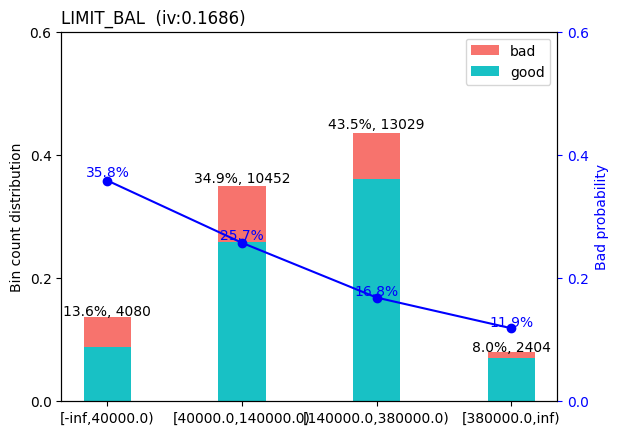

In [19]:
# Bin features and apply WoE transformation
bins = sc.woebin(df, y='default')

# Visualise WoE bins for a feature
sc.woebin_plot(bins['LIMIT_BAL'])

# Apply WoE transformation to entire dataframe
df_woe = sc.woebin_ply(df, bins)
df_woe.head()

{'LIMIT_BAL': <Figure size 640x480 with 2 Axes>}

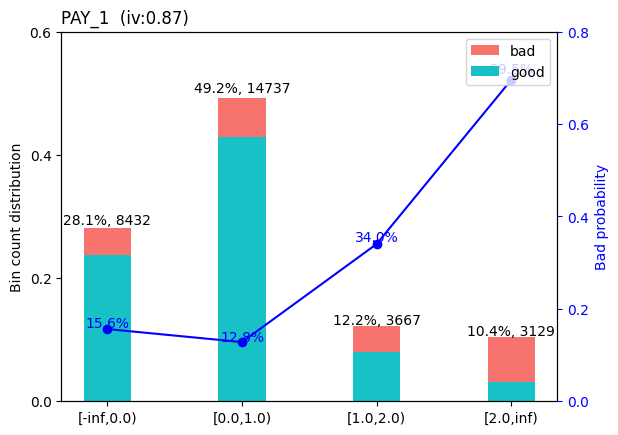

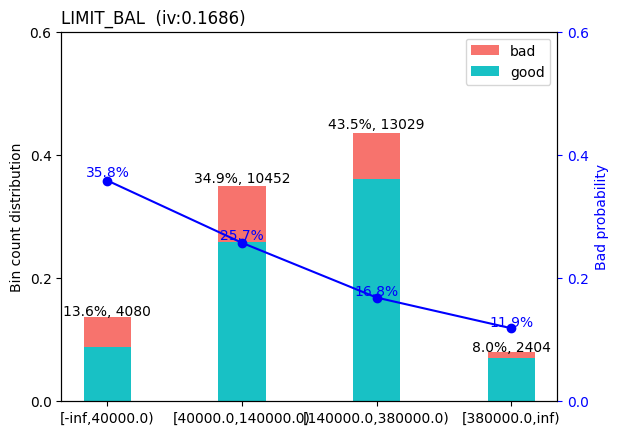

In [20]:
#Bivariate EDA (Target Rate by Bin)

sc.woebin_plot(bins['PAY_1'])   # See how default rate changes across repayment status bins
sc.woebin_plot(bins['LIMIT_BAL'])

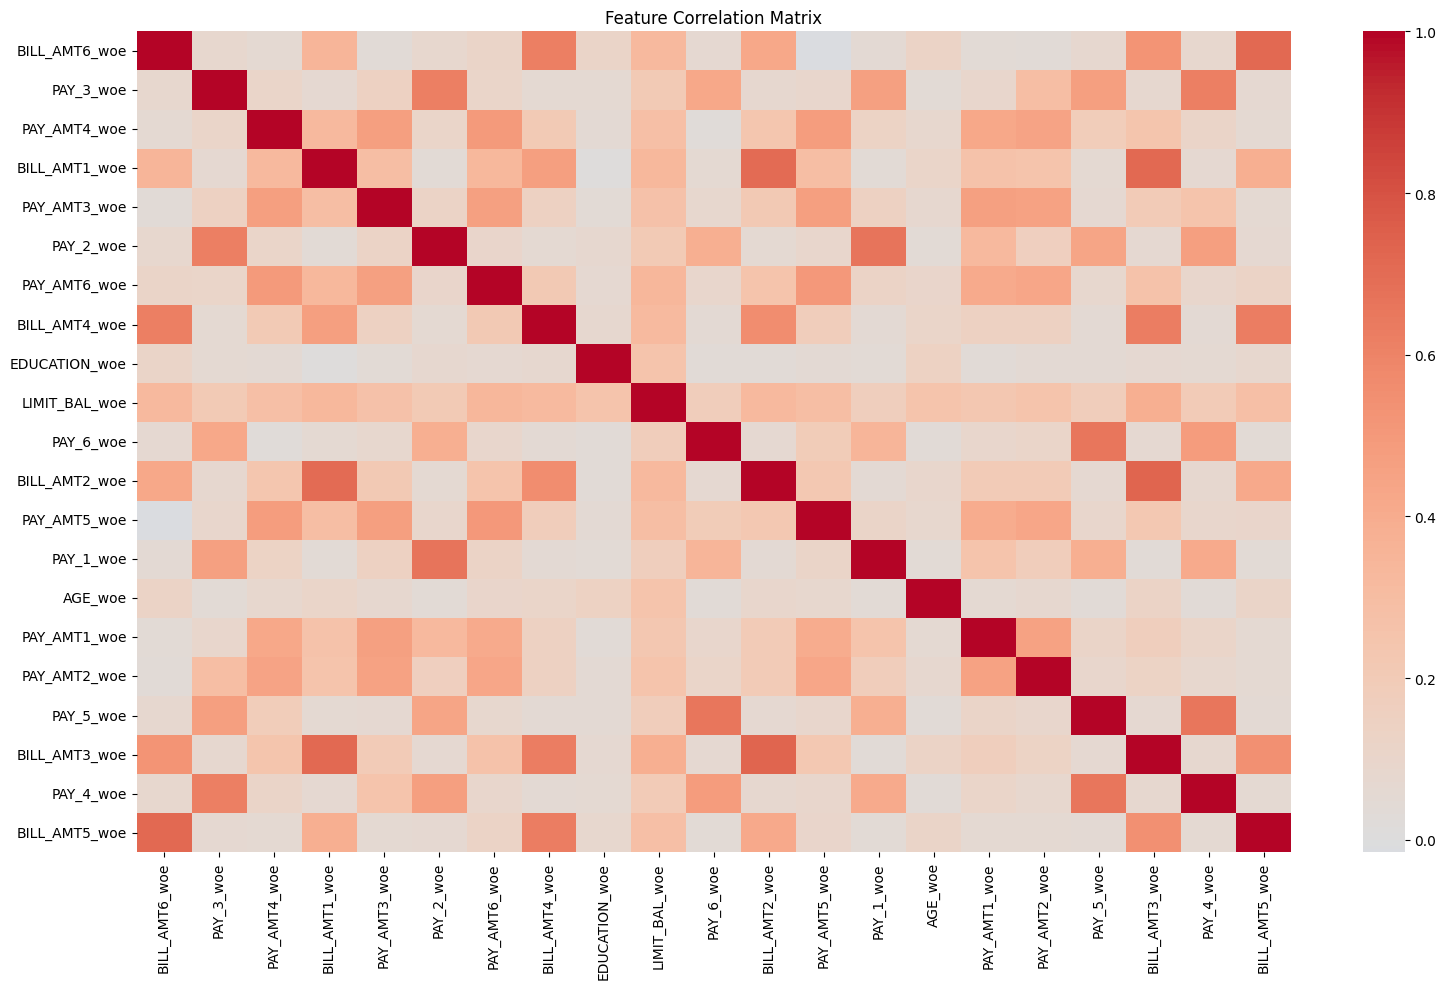

Highly correlated features to drop (>0.90): []


In [21]:
#Correlation Matrix

plt.figure(figsize=(16, 10))
corr_matrix = df_woe.drop(columns=['default']).corr()

sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Programmatically find highly correlated pairs
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [col for col in upper_tri.columns if any(upper_tri[col].abs() > 0.90)]
print(f"Highly correlated features to drop (>0.90): {to_drop_corr}")

df_woe.drop(columns=to_drop_corr, inplace=True)

In [22]:
#7 VIF (Variance Inflation Factor)

from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_data = pd.DataFrame()
    vif_data['feature'] = data.columns
    vif_data['VIF'] = [variance_inflation_factor(data.values, i)
                       for i in range(data.shape[1])]
    return vif_data.sort_values('VIF', ascending=False)

X = df_woe.drop(columns=['default'])
print(calculate_vif(X))

          feature       VIF
18  BILL_AMT3_woe  3.269233
5       PAY_2_woe  2.777520
17      PAY_5_woe  2.736394
19      PAY_4_woe  2.643077
3   BILL_AMT1_woe  2.632701
11  BILL_AMT2_woe  2.620617
1       PAY_3_woe  2.591434
0   BILL_AMT6_woe  2.461225
20  BILL_AMT5_woe  2.408978
7   BILL_AMT4_woe  2.271746
10      PAY_6_woe  2.036432
13      PAY_1_woe  1.941287
4    PAY_AMT3_woe  1.879780
2    PAY_AMT4_woe  1.874900
16   PAY_AMT2_woe  1.868370
15   PAY_AMT1_woe  1.832883
12   PAY_AMT5_woe  1.795705
6    PAY_AMT6_woe  1.713735
9   LIMIT_BAL_woe  1.549261
8   EDUCATION_woe  1.090401
14        AGE_woe  1.081034


In [23]:
# Iteratively drop highest VIF feature until all VIF < 2
def iterative_vif_removal(data, threshold=2.0):
    dropped = []
    while True:
        vif = calculate_vif(data)
        max_vif = vif['VIF'].max()
        if max_vif <= threshold:
            break
        worst_feature = vif.loc[vif['VIF'].idxmax(), 'feature']
        print(f"Dropping '{worst_feature}' with VIF = {max_vif:.2f}")
        data = data.drop(columns=[worst_feature])
        dropped.append(worst_feature)
    print(f"\nDone. Dropped features: {dropped}")
    return data

X_clean = iterative_vif_removal(X, threshold=2.0)

Dropping 'BILL_AMT3_woe' with VIF = 3.27
Dropping 'PAY_2_woe' with VIF = 2.78
Dropping 'PAY_5_woe' with VIF = 2.73
Dropping 'BILL_AMT6_woe' with VIF = 2.44
Dropping 'BILL_AMT2_woe' with VIF = 2.30
Dropping 'PAY_3_woe' with VIF = 2.12

Done. Dropped features: ['BILL_AMT3_woe', 'PAY_2_woe', 'PAY_5_woe', 'BILL_AMT6_woe', 'BILL_AMT2_woe', 'PAY_3_woe']


In [24]:
#Class Imbalance Treatment

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Define X and y
y = df_woe['default']
X_clean = df_woe.drop(columns=['default'])

# Split FIRST, then SMOTE
X_train, X_test, y_train, y_test = train_test_split(X_clean, y, test_size=0.2, random_state=42)

# Apply SMOTE only on training data
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# Verify
print("Train before SMOTE:", y_train.value_counts().to_dict())
print("Train after SMOTE: ", y_train_res.value_counts().to_dict())
print("Test (untouched):  ", y_test.value_counts().to_dict())

Train before SMOTE: {0: 18662, 1: 5310}
Train after SMOTE:  {0: 18662, 1: 18662}
Test (untouched):   {0: 4673, 1: 1320}


In [25]:
print("Final features going into the model:\n")
print(X_train_res.columns.tolist())
print(f"\nTotal features: {X_train_res.shape[1]}")
print(f"Total training samples: {X_train_res.shape[0]}")

Final features going into the model:

['BILL_AMT6_woe', 'PAY_3_woe', 'PAY_AMT4_woe', 'BILL_AMT1_woe', 'PAY_AMT3_woe', 'PAY_2_woe', 'PAY_AMT6_woe', 'BILL_AMT4_woe', 'EDUCATION_woe', 'LIMIT_BAL_woe', 'PAY_6_woe', 'BILL_AMT2_woe', 'PAY_AMT5_woe', 'PAY_1_woe', 'AGE_woe', 'PAY_AMT1_woe', 'PAY_AMT2_woe', 'PAY_5_woe', 'BILL_AMT3_woe', 'PAY_4_woe', 'BILL_AMT5_woe']

Total features: 21
Total training samples: 37324


In [26]:
#Step 1: Fit Initial Logistic Regression (Why statsmodels and not sklearn? Because statsmodels gives you p-values and coefficients directly — essential for backward elimination. sklearn doesn't provide p-values.)

import statsmodels.api as sm

# Add constant (intercept)
X_train_const = sm.add_constant(X_train_res)

# Fit model
logit_model = sm.Logit(y_train_res, X_train_const)
result = logit_model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.564335
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                37324
Model:                          Logit   Df Residuals:                    37302
Method:                           MLE   Df Model:                           21
Date:                Sun, 19 Apr 2026   Pseudo R-squ.:                  0.1858
Time:                        17:32:32   Log-Likelihood:                -21063.
converged:                       True   LL-Null:                       -25871.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.0089      0.012     -0.741      0.459      -0.033       0.015
BILL_AMT6_woe     0.

In [27]:
#Step 2: Backward Elimination — Remove p-value > 0.01

def backward_elimination(X, y, threshold=0.05):
    cols = list(X.columns)
    while True:
        X_const = sm.add_constant(X[cols])
        result = sm.Logit(y, X_const).fit(disp=0)  # disp=0 silences iteration log

        p_values = result.pvalues.drop('const')
        max_pval = p_values.max()

        if max_pval > threshold:
            worst = p_values.idxmax()
            print(f"Dropping '{worst}' with p-value = {max_pval:.4f}")
            cols.remove(worst)
        else:
            print(f"\nDone! All remaining variables have p-value < {threshold}")
            break

    return result, cols

final_result, final_cols = backward_elimination(X_train_res, y_train_res)
print(f"\nFinal variables ({len(final_cols)}): {final_cols}")

Dropping 'BILL_AMT4_woe' with p-value = 0.4186
Dropping 'PAY_2_woe' with p-value = 0.2717
Dropping 'BILL_AMT6_woe' with p-value = 0.2097
Dropping 'BILL_AMT2_woe' with p-value = 0.1733
Dropping 'PAY_AMT5_woe' with p-value = 0.1139

Done! All remaining variables have p-value < 0.05

Final variables (16): ['PAY_3_woe', 'PAY_AMT4_woe', 'BILL_AMT1_woe', 'PAY_AMT3_woe', 'PAY_AMT6_woe', 'EDUCATION_woe', 'LIMIT_BAL_woe', 'PAY_6_woe', 'PAY_1_woe', 'AGE_woe', 'PAY_AMT1_woe', 'PAY_AMT2_woe', 'PAY_5_woe', 'BILL_AMT3_woe', 'PAY_4_woe', 'BILL_AMT5_woe']


In [31]:
#Step 3: Odds Ratios — The "e to the power" Part

import numpy as np

odds_ratios = pd.DataFrame({
    'Coefficient': final_result.params,
    'Odds Ratio':  np.exp(final_result.params),
    'p-value':     final_result.pvalues
}).drop('const').sort_values('Odds Ratio', ascending=False)

print(odds_ratios)

               Coefficient  Odds Ratio       p-value
BILL_AMT5_woe     0.855497    2.352544  2.206069e-08
PAY_1_woe         0.735435    2.086390  0.000000e+00
EDUCATION_woe     0.586264    1.797261  9.275124e-09
LIMIT_BAL_woe     0.533894    1.705561  1.176498e-50
PAY_AMT4_woe      0.340305    1.405376  2.328348e-10
PAY_AMT1_woe      0.313403    1.368073  1.262169e-17
PAY_AMT2_woe      0.298359    1.347645  6.119561e-13
PAY_6_woe         0.283914    1.328318  6.970066e-19
PAY_AMT6_woe      0.224544    1.251752  1.363184e-05
AGE_woe           0.222427    1.249105  9.751769e-03
PAY_4_woe         0.207528    1.230632  2.703252e-10
PAY_3_woe         0.203088    1.225180  2.488550e-14
PAY_AMT3_woe      0.202766    1.224786  2.180842e-05
PAY_5_woe         0.093129    1.097603  8.250185e-03
BILL_AMT1_woe    -1.342577    0.261172  1.459467e-09
BILL_AMT3_woe    -1.767591    0.170744  7.634673e-13


In [32]:
#Step 4: Feature Importance via Coefficients

coef_importance = pd.DataFrame({
    'Feature': final_cols,
    'Coefficient': final_result.params[1:],  # exclude const
    'Abs_Coefficient': abs(final_result.params[1:])
}).sort_values('Abs_Coefficient', ascending=False)

print(coef_importance)

                     Feature  Coefficient  Abs_Coefficient
BILL_AMT3_woe  BILL_AMT3_woe    -1.767591         1.767591
BILL_AMT1_woe  BILL_AMT1_woe    -1.342577         1.342577
BILL_AMT5_woe  BILL_AMT5_woe     0.855497         0.855497
PAY_1_woe          PAY_1_woe     0.735435         0.735435
EDUCATION_woe  EDUCATION_woe     0.586264         0.586264
LIMIT_BAL_woe  LIMIT_BAL_woe     0.533894         0.533894
PAY_AMT4_woe    PAY_AMT4_woe     0.340305         0.340305
PAY_AMT1_woe    PAY_AMT1_woe     0.313403         0.313403
PAY_AMT2_woe    PAY_AMT2_woe     0.298359         0.298359
PAY_6_woe          PAY_6_woe     0.283914         0.283914
PAY_AMT6_woe    PAY_AMT6_woe     0.224544         0.224544
AGE_woe              AGE_woe     0.222427         0.222427
PAY_4_woe          PAY_4_woe     0.207528         0.207528
PAY_3_woe          PAY_3_woe     0.203088         0.203088
PAY_AMT3_woe    PAY_AMT3_woe     0.202766         0.202766
PAY_5_woe          PAY_5_woe     0.093129         0.0931

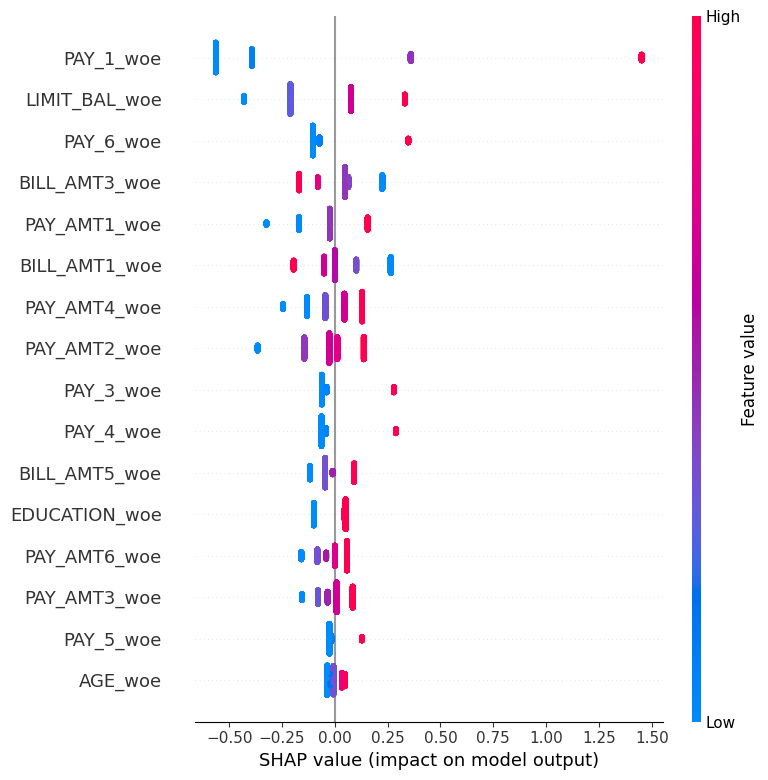

In [33]:
#Step 5: SHAP Values — Advanced Feature Importance

import shap
from sklearn.linear_model import LogisticRegression

# Refit with sklearn for SHAP compatibility
lr = LogisticRegression(random_state=42)
lr.fit(X_train_res[final_cols], y_train_res)

# SHAP explainer
explainer = shap.LinearExplainer(lr, X_train_res[final_cols])
shap_values = explainer.shap_values(X_test[final_cols])

# Summary plot
shap.summary_plot(shap_values, X_test[final_cols])

Building the Random Forest Model

In [34]:
#Step1: Build the Base RF Model
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train_res[final_cols], y_train_res)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [35]:
#Step2: Hyperparameter Tuning via GridSearchCV
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 5]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid.fit(X_train_res[final_cols], y_train_res)

best_rf = grid.best_estimator_
print(grid.best_params_)

{'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}


<Axes: title={'center': 'RF Feature Importance'}>

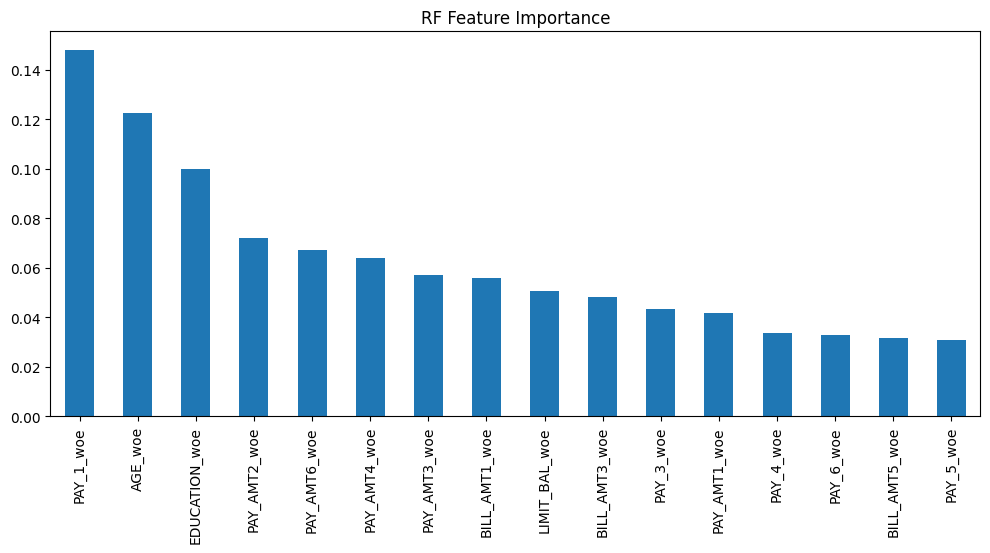

In [36]:
#Step3: Feature Importance (RF's inbuilt)
importances = pd.Series(best_rf.feature_importances_,
                         index=final_cols).sort_values(ascending=False)
importances.plot(kind='bar', figsize=(12,5), title='RF Feature Importance')

In [37]:
#Step4: Model Evaluation — same metrics as LR for comparison
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

y_pred_rf = best_rf.predict(X_test[final_cols])
y_prob_rf = best_rf.predict_proba(X_test[final_cols])[:,1]

print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      4673
           1       0.51      0.41      0.46      1320

    accuracy                           0.78      5993
   macro avg       0.67      0.65      0.66      5993
weighted avg       0.77      0.78      0.77      5993

ROC-AUC: 0.7200


In [38]:
#Now run the same evaluation metrics on your Logistic Regression model so we can do a side by side comparison:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_res[final_cols], y_train_res)

y_pred_lr = lr.predict(X_test[final_cols])
y_prob_lr = lr.predict_proba(X_test[final_cols])[:,1]

print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")

              precision    recall  f1-score   support

           0       0.88      0.82      0.85      4673
           1       0.48      0.59      0.53      1320

    accuracy                           0.77      5993
   macro avg       0.68      0.70      0.69      5993
weighted avg       0.79      0.77      0.78      5993

ROC-AUC: 0.7663


Final Conclusion

"Logistic Regression with WoE transformation outperformed Random Forest on this dataset — particularly on defaulter recall (0.59 vs 0.42) and ROC-AUC (0.77 vs 0.72). This is because WoE pre-processing linearised feature relationships, eliminating RF's primary advantage. For a regulated environment sector like this, LR is also the preferred choice due to its interpretability, coefficient explainability, and compliance-friendliness, making it the final recommended model."